In [1]:
import pdfplumber
import pandas as pd
import re
import os
import matplotlib.pyplot as plt

In [2]:
def clean_val(val):
    if val is None or val == '-': return None
    # Fix the unicode minus sign (−) and the ± symbol
    clean_str = str(val).split('±')[0].replace('−', '-').replace(" ", "")
    try:
        return float(clean_str)
    except:
        return None


In [3]:
folder_path = r"C:\pea\code\parameter_guesser"
exclude = ['.ipynb_checkpoints','.venv','circuits']
folders = [f.name for f in os.scandir(folder_path) 
           if f.is_dir() and not any(x in f.name for x in exclude)]
print(folders)

['8HQ', 'BTA', 'Lcystine', 'MBT', 'Molybdate', 'NaCl', 'NaVO3']


In [38]:
all_data = []
for compound in folders:
    file_path = rf"C:\pea\code\parameter_guesser\{compound}\good_data"
    # Loop through your files
    for filename in os.listdir(file_path):
        if filename.endswith(".pdf"):
            path = os.path.join(file_path, filename)
            with pdfplumber.open(path) as pdf:
                table = pdf.pages[0].extract_table({"vertical_strategy": "lines", "horizontal_strategy": "lines"})
                if not table: continue
                
                df_temp = pd.DataFrame(table[1:], columns=table[0])

                filename_hours = [int(h) for h in re.findall(r'_(\d+)H(?=_|$)', filename)]
                filename_circuit = re.findall(r'(\d+)RC', filename)
                #print(filename_circuit)
                if not filename_hours: continue
                
                for _, row in df_temp.iterrows():
                    element = row['Element']

                    circuit_num = int(filename_circuit[0]) if filename_circuit else 1
    
                    if circuit_num == 2:
                        # Swap R1/R2, n1/n2, Q1/Q2
                        swap_map = {'R1': 'R2', 'R2': 'R1', 'n1': 'n2', 'n2': 'n1', 'Q1': 'Q2', 'Q2': 'Q1'}
                        element = swap_map.get(element, element)
                
                    elif circuit_num == 3:
                        # Swap R1/R3, n1/n3, Q1/Q3
                        swap_map = {'R1': 'R3', 'R3': 'R1', 'n1': 'n3', 'n3': 'n1', 'Q1': 'Q3', 'Q3': 'Q1'}
                        element = swap_map.get(element, element)
        
                    for col in df_temp.columns:
                        col_hour_match = re.search(r'(\d+)H\b', str(col))

                        if col_hour_match:
                            col_hour = int(col_hour_match.group(1))
                            #print(col_hour)
                            if col_hour in filename_hours:
                                val = clean_val(row[col])
                                #print(val)
                                all_data.append({
                                    'compound': compound,
                                    'element': element, 
                                    'hour': col_hour, 
                                    'value': val
                                })



In [39]:
df_master = pd.DataFrame(all_data)

# Pivot to have both Element and Compound as rows, and Hours as columns
df_pivot = df_master.pivot_table(
    index=['element', 'compound'], 
    columns='hour', 
    values='value', 
    aggfunc='first'
)

# Sort columns (hours) numerically
df_pivot = df_pivot.reindex(sorted(df_pivot.columns), axis=1)


In [40]:
df_r1 = df_pivot.xs('R1', level='element')

print("--- R1 Values Across All Compounds ---")
print(df_r1)


--- R1 Values Across All Compounds ---
hour            1         4         8          24         48           72   \
compound                                                                     
8HQ         52100.0   42300.0   40400.0    33100.0    23600.0      19400.0   
BTA         88600.0   89300.0   53300.0    57900.0    44000.0      34400.0   
Lcystine   145000.0  193000.0  221000.0   319000.0   244000.0     310000.0   
MBT        355000.0  539000.0  669000.0  1000000.0  1250000.0  100000000.0   
Molybdate    8980.0    8390.0   11300.0    10800.0    38100.0      11500.0   
NaCl         3880.0    6050.0   23600.0    29600.0    30500.0      42600.0   
NaVO3      179000.0  242000.0  311000.0   314000.0   270000.0     279000.0   

hour             168  
compound              
8HQ          14000.0  
BTA          24900.0  
Lcystine    410000.0  
MBT        1390000.0  
Molybdate    11300.0  
NaCl         15700.0  
NaVO3       266000.0  


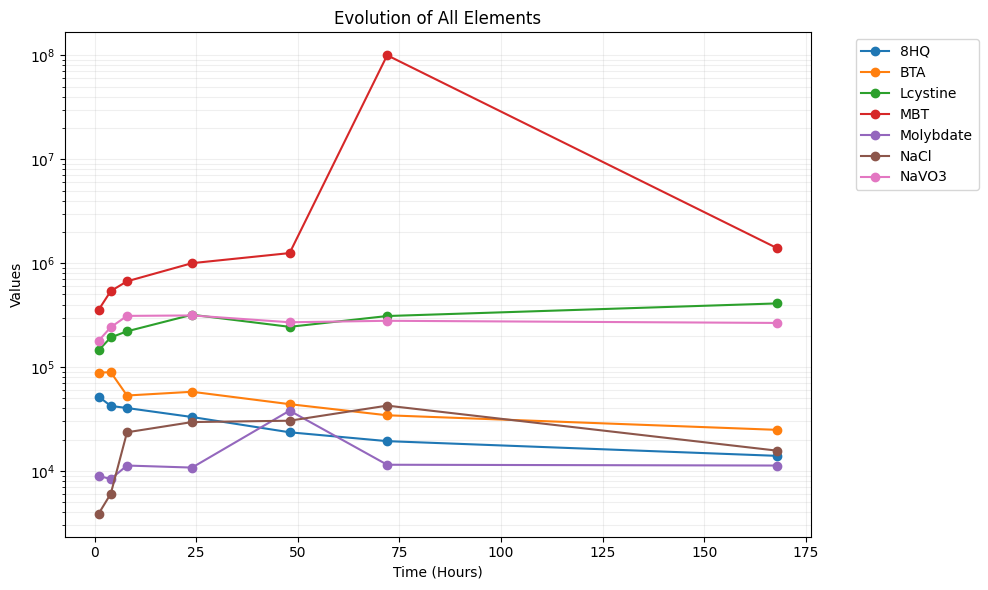

In [46]:
import matplotlib.pyplot as plt

df_r1 = df_pivot.xs('R1', level='element')
plt.figure(figsize=(10, 6))
hours = df_r1.columns.values

for compound in df_r1.index:
    # Use .dropna() if you want the lines to connect across NaN values
    y_values = df_r1.loc[compound].values
    plt.plot(hours, y_values, marker='o', label=compound)

plt.title("Evolution of All Elements")
plt.xlabel("Time (Hours)")
plt.ylabel("Values")
plt.yscale('log')  # Recommended because your values range from 10^-6 to 10^2
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()
